# Week-1

**Note to Learners**:

- Click on "Copy to Drive", the button that appears just below the taskbar, to make a copy of this notebook in your drive. If you continue working with this notebook, changes **will not** be saved.


- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

We will be working with a subset of the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database). Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. You will be using this dataset for the rest of the assignment. Do not edit this cell.

In [1]:
##### DATASET GENERATION #####
import numpy as np
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = X_train[y_train == 2][: 100].reshape(-1, 28 * 28)
test_image = X_test[y_test == 2][0].reshape(28 * 28)
##### DO NOT EDIT THIS CELL #####

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Problem-1

How many samples does the dataset have?

In [2]:
# Enter your solution here
num_samples = X.shape[0]
num_samples

100

## Problem-2

How many features does the dataset have?

In [3]:
# Enter your solution here
num_features = X.shape[1]
num_features

784

## Problem-3

Each sample corresponds to an image of dimension $28 \times 28$. Visualize one of these images using the `matplotlib` library.

- You need to know how to reshape a feature vector. Refer to week-0 content for the same.
- You can refer to the following [document](https://matplotlib.org/stable/tutorials/introductory/images.html#sphx-glr-tutorials-introductory-images-py) for plotting NumPy arrays as images using `matplotlib`.

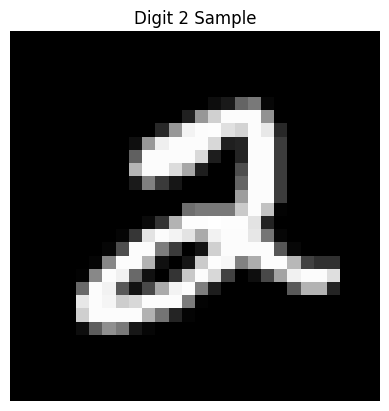

In [4]:
# Enter your solution here

import matplotlib.pyplot as plt
image = X[0].reshape(28, 28)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title("Digit 2 Sample")
plt.show()

## Problem-4

Center the the dataset $\mathbf{X}$ around its mean. Call this centered dataset $\mathbf{X}^{\prime}$.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{n \cdot d} \sqrt{\sum \limits_{i = 1}^{n} \sum \limits_{j = 1}^{d} (X_{ij}^{\prime})^2}
$$

In [5]:
# Enter your solution here
mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

n, d = X_centered.shape

value = np.sqrt(np.sum(X_centered**2) / (n * d))
round(value, 2)

np.float64(65.08)

## Problem-5

Compute the covariance matrix $\mathbf{C}$ of the centered dataset.

<u>Conversion</u>

Enter the following quantity as your answer correct to two decimal places:

$$
\cfrac{1}{d^2} \sqrt{\sum \limits_{i = 1}^{d} \sum \limits_{j = 1}^{d} C_{ij}^2}
$$

In [6]:
# Enter your solution here
C = np.cov(X_centered, rowvar=False)

value = np.sqrt(np.sum(C**2) / (d * d))
round(value, 2)

np.float64(1080.82)

## Problem-6

Compute the first and second principal components of the dataset, $\mathbf{w}_1$ and $\mathbf{w}_2$.

<u>Conversion</u>

Compute:
$$
\mathbf{w} = \mathbf{w}_1 + \mathbf{w}_2
$$

Enter the following quantity as your answer correct to two decimal places:

$$
\left| \sum \limits_{i = 1}^{d} w_i \right|
$$

In [7]:
# Enter your solution here
eigenvalues, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

w1 = eigenvectors[:, 0]
w2 = eigenvectors[:, 1]

w = w1 + w2
value = abs(np.sum(w))
round(value, 2)


np.float64(1.05)

## Problem-7

Visualize the first principal component as an image.

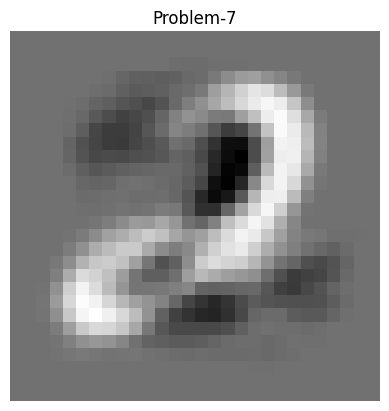

In [8]:
# Enter your solution here
pc1_image = w1.reshape(28, 28)

plt.imshow(pc1_image, cmap='gray')
plt.axis('off')
plt.title("Problem-7")
plt.show()


## Problem-8

Find the smallest value of $k$ for which the first $k$ principal components capture at least $95\%$ of the variance in the data.

In [9]:
# Enter your solution here
explained_variance_ratio = eigenvalues[idx] / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

k_95 = np.argmax(cumulative_variance >= 0.95) + 1
k_95


np.int64(53)

## Problem-9

Given a `test_image`, visualize the proxies  by reconstructing it using the top $k$ principal components. Consider four values of $k$; values of $k$ for which the top-$k$ principal components explain:

- 20% of the variance
- 50% of the variance
- 80% of the variance
- 95% of the variance



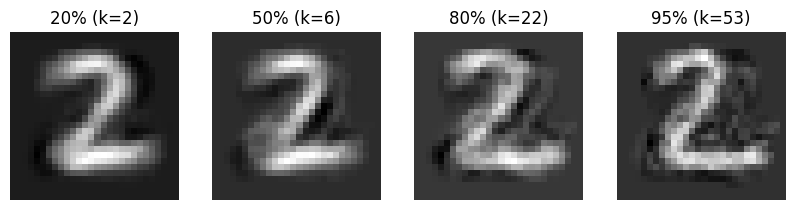

In [10]:
# Enter your solution here
def reconstruct(image, eigenvectors, mean, k):
    proj = (image - mean) @ eigenvectors[:, :k]
    return proj @ eigenvectors[:, :k].T + mean

targets = [0.20, 0.50, 0.80, 0.95]
ks = [np.argmax(cumulative_variance >= t) + 1 for t in targets]

plt.figure(figsize=(10, 3))

for i, k in enumerate(ks):
    recon = reconstruct(test_image, eigenvectors, mean_X, k)
    plt.subplot(1, 4, i + 1)
    plt.imshow(recon.reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"{int(targets[i]*100)}% (k={k})")

plt.show()
